# 23CSE301 Machine Learning — Capstone Project
## Regression Track — Student Performance

**Track owner:** _(team member name — see `docs/team_contributions.md`)_
**Review:** Review 1 (full track)
**Dataset:** Student Performance (Multiple Linear Regression) — `Student_Performance.csv`
**Source:** https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression

---

### How this notebook is organised
Every pipeline step calls the shared implementation in `src/`, which is the same
code that `scripts/run_all.py` executes. That keeps the notebook and the scripts
from drifting apart and means no result shown here is computed twice in two
different ways.

**On AI assistance:** code scaffolding in this project was generated with an AI
assistant (see `README.md` § AI-Assistance Disclosure). Every cell marked
**✍️ TEAM TO COMPLETE** must be written by the team. Those cells are empty on
purpose.

## 0. Environment and shared configuration

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # project root on the path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_loading as dl, preprocessing as pp
from src import feature_engineering as fe, evaluation as ev, plotting as pl

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("default")      # warnings stay visible on purpose

print("random_state =", config.RANDOM_STATE, "| test_size =", config.TEST_SIZE,
      "| cv folds =", config.CV_FOLDS)

random_state = 42 | test_size = 0.2 | cv folds = 5


## 1. Data loading and audit  *(Rubric A1)*
Raw file is read from `data/raw/` and left untouched. Shape, dtypes,
missing-value counts and the target distribution are all reported below.

In [2]:
raw = dl.load_raw("regression")
print("\nAudit summary:")
summary = dl.audit_summary(raw, "regression")
for k, v in summary.items():
    print(f"  {k}: {v}")

[load_raw] regression: Student_Performance.csv -> shape (10000, 6) (expected (10000, 6))

Audit summary:
  track: regression
  shape: (10000, 6)
  n_duplicate_rows: 127
  total_missing_cells: 0
  columns: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']
  target: Performance Index
  target_present: True
  target_describe: {'count': 10000.0, 'mean': 55.2248, 'std': 19.212557799463344, 'min': 10.0, '25%': 40.0, '50%': 55.0, '75%': 71.0, 'max': 100.0}


In [3]:
dl.audit(raw, "regression", "raw")

,column,dtype,missing,missing_pct,n_unique,example
0,Hours Studied,int64,0,0.0,9,7
1,Previous Scores,int64,0,0.0,60,99
2,Extracurricular Activities,str,0,0.0,2,Yes
3,Sleep Hours,int64,0,0.0,6,9
4,Sample Question Papers Practiced,int64,0,0.0,10,1
5,Performance Index,float64,0,0.0,91,91.0


In [4]:
raw.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours Studied,10000.0,NaN,NaN,NaN,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
Previous Scores,10000.0,NaN,NaN,NaN,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
Extracurricular Activities,10000,2,No,5052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep Hours,10000.0,NaN,NaN,NaN,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,10000.0,NaN,NaN,NaN,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
Performance Index,10000.0,NaN,NaN,NaN,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0


### 1.1 Duplicate records — a decision the team must confirm
127 exact duplicate rows exist. All five inputs are low-cardinality integers or
a binary flag, so identical rows arise by coincidence in a synthetic 10,000-row
sample. Removing them would drop the prepared set to 9,873 rows, **below the
10,000-row working preference**. The reported run RETAINS them; the alternative
is measured below so the team can decide on evidence.

In [6]:
df = dl.prepare("regression", raw)
dedup = pp.drop_exact_duplicates(df)
print(f"\nretained : {len(df)} rows  (the reported configuration)")
print(f"if dropped: {len(dedup)} rows  -> below the 10,000 preference: {len(dedup) < 10000}")

[prepare] regression: raw (10000, 6) -> prepared (10000, 6) (6 columns kept)
  excluded: []
[dedup] 10000 -> 9873 rows (127 exact duplicates removed)

retained : 10000 rows  (the reported configuration)
if dropped: 9873 rows  -> below the 10,000 preference: True


> ### ✍️ TEAM TO COMPLETE — Duplicate-handling decision (Q-RG1)
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Are these duplicated rows plausible coincidences given the feature cardinality, or do they look like a data-collection artefact?
> 2. Which option do you choose, and what is your justification?
> 3. What effect, if any, could retaining them have on the train/test comparison?
>
> ---
>
> *(your written observation here)*

## 2. Exploratory data analysis  *(Rubric A2, A3)*
Distribution plot for every input feature, correlation heatmap, target
distribution, and two feature–target scatter plots.

In [7]:
feats = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced'] + ['Extracurricular Activities']
p = pl.distribution_grid(df[feats], "Student Performance - input feature distributions",
                         "nb_reg_feature_distributions", "regression")

[fig] results/figures/regression/nb_reg_feature_distributions.png


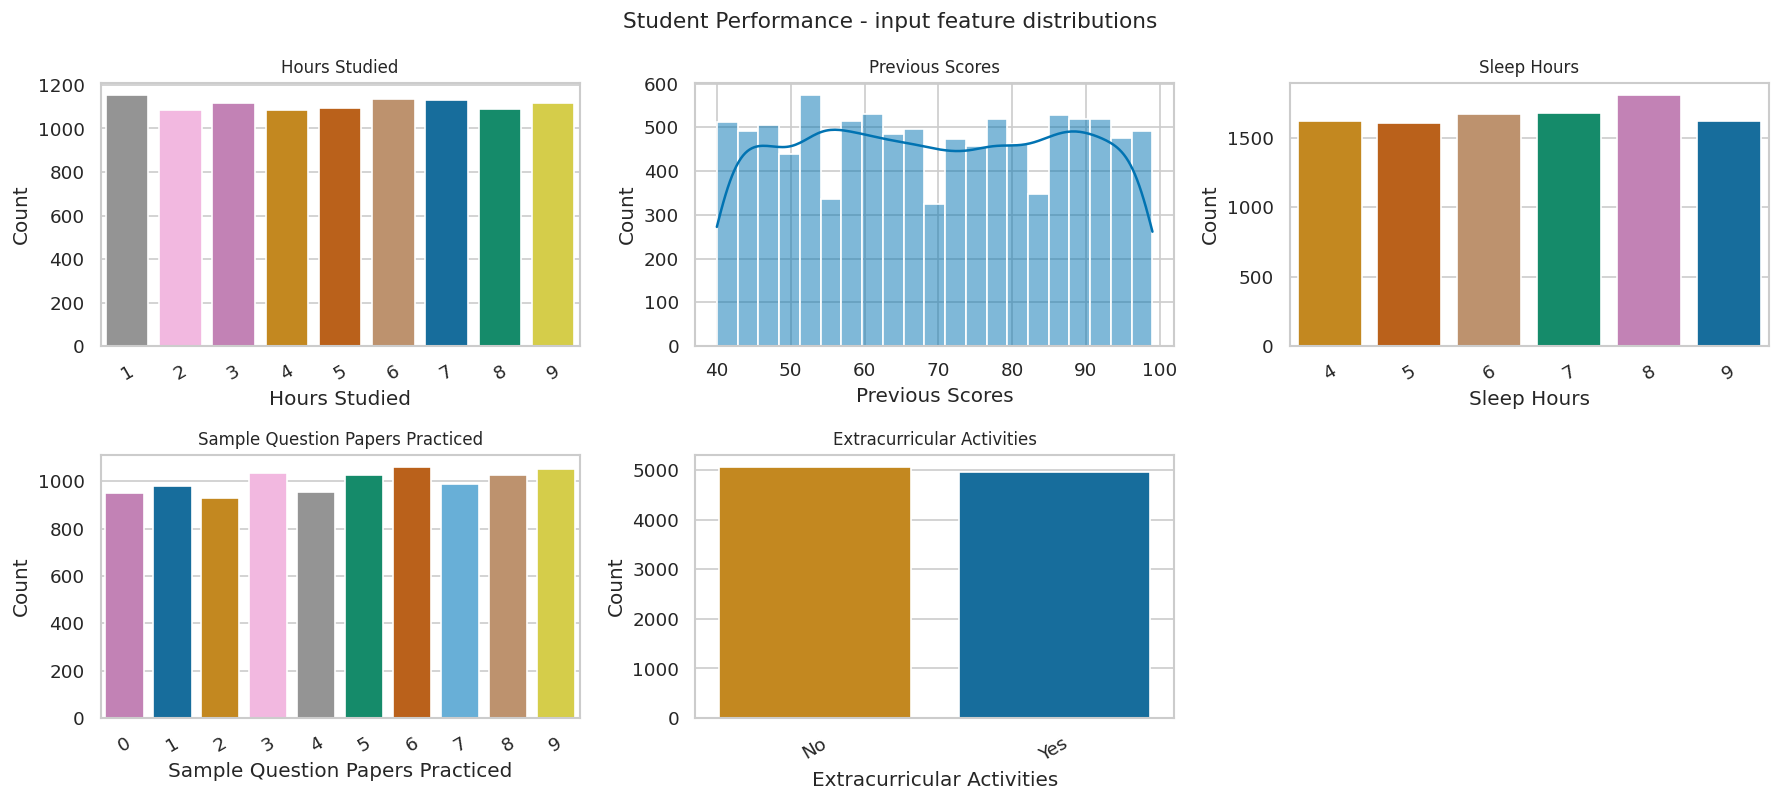

In [8]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Feature distributions
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Which features are roughly uniform, and which are skewed?
> 2. Does any feature show an implausible value or a suspicious spike?
> 3. What does the shape of each distribution imply for scaling or for the models that assume normality?
>
> ---
>
> *(your written observation here)*

In [9]:
p = pl.correlation_heatmap(df, "Student Performance - correlation heatmap (numeric)",
                           "nb_reg_correlation_heatmap", "regression")

[fig] results/figures/regression/nb_reg_correlation_heatmap.png


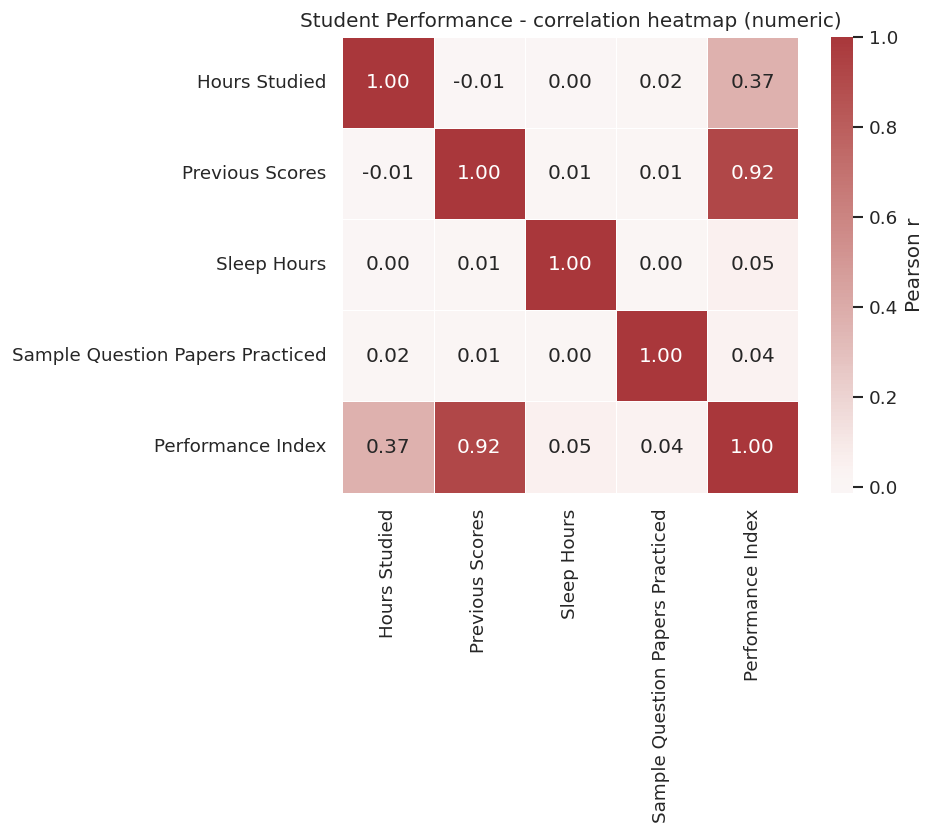

In [10]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Correlation structure
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Which input correlates most strongly with Performance Index?
> 2. Is there any correlation between inputs high enough to raise a multicollinearity concern for the linear models?
> 3. Does the correlation ranking match what you would expect from the domain?
>
> ---
>
> *(your written observation here)*

In [11]:
p = pl.target_distribution(df['Performance Index'], "Target distribution - Performance Index",
                           "nb_reg_target_distribution", "regression")

[fig] results/figures/regression/nb_reg_target_distribution.png


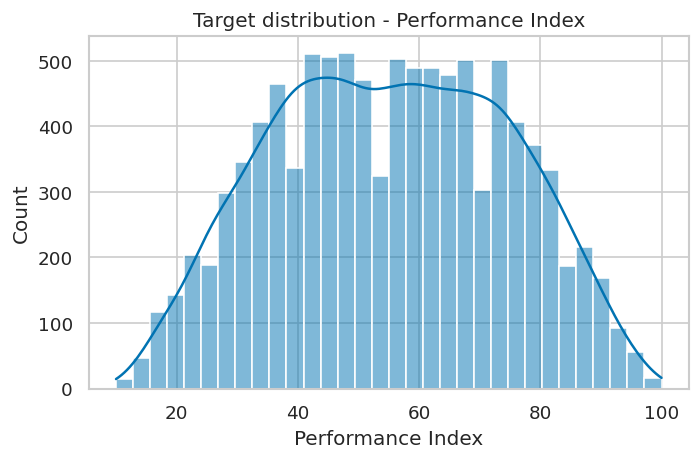

In [12]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [13]:
corr_t = df.select_dtypes("number").corr()['Performance Index'].drop('Performance Index')
top2 = corr_t.abs().sort_values(ascending=False).index[:2].tolist()
print("two strongest linear relationships with the target:", top2)
p = pl.feature_target_scatter(df, top2, 'Performance Index', "nb_reg_feature_target_scatter", "regression")

two strongest linear relationships with the target: ['Previous Scores', 'Hours Studied']


[fig] results/figures/regression/nb_reg_feature_target_scatter.png


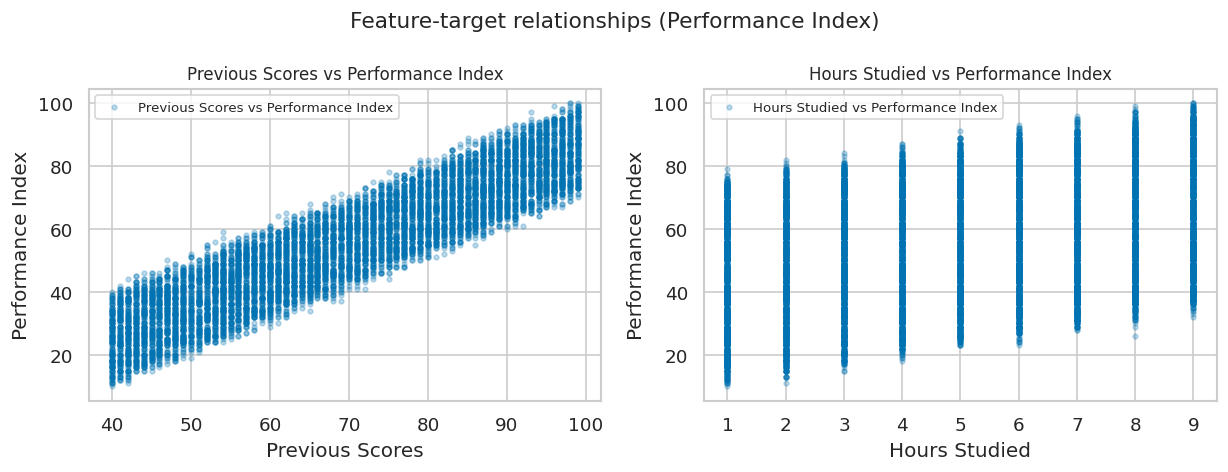

In [14]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Feature–target relationships
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Is each relationship linear, curved, or absent?
> 2. How much vertical spread is there at a fixed x — i.e. how much variance can this feature alone not explain?
> 3. Does this support or undermine a linear model as the baseline?
>
> ---
>
> *(your written observation here)*

## 3. Preprocessing and the held-out split  *(Rubric B1, B2)*
The split is made **before** any data-driven modelling decision. Imputation,
one-hot encoding and scaling all live inside pipelines, so each is refitted on
the training part of every CV fold — never on the full dataset.

**Stratification note.** Rubric B2 asks for a stratified split. Stratification
is defined for discrete classes; the target here is continuous. The project
therefore uses an unstratified random split and records the ambiguity in
`docs/instructor_clarifications.md` (IC-2). `pp.split_supervised(...,
stratify_bins=k)` implements quantile-binned stratification if the instructor
confirms it is wanted.

In [15]:
X_train, X_test, y_train, y_test = pp.split_supervised(df, 'Performance Index', stratify=False)
print(pp.check_no_row_leakage(X_train, X_test))

[split] train=(8000, 5) test=(2000, 5) stratify=none
{'test_rows': 2000, 'test_rows_also_in_train': 258, 'pct': 12.9}


> ### ✍️ TEAM TO COMPLETE — Train/test overlap (Q-RG2)
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. The overlap report counts test rows whose feature values also appear in training. Why does this number look large here, and is it 'leakage' in the harmful sense?
> 2. Would deduplicating before splitting change your answer?
>
> ---
>
> *(your written observation here)*

### 3.1 Feature engineering  *(Rubric B3)* — ⚠️ NOT YET SATISFIED
`src/feature_engineering.py` ships an empty hook. Until the team registers a
feature **and its justification**, the baseline pipeline runs and this rubric
item is reported INCOMPLETE. The AI assistant deliberately did not invent one.

In [16]:
fe.status("regression")

{'track': 'regression',
 'state': 'AWAITING TEAM INPUT',
 'rubric_B3': 'INCOMPLETE',
 'detail': 'No engineered feature registered; baseline pipeline executed.'}

> ### ✍️ TEAM TO COMPLETE — Engineered feature (Q-RG3) — required for rubric B3
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Which new feature will you create, from which existing columns?
> 2. What is your reasoning for why it should help — before you look at whether it does?
> 3. After registering it in src/feature_engineering.py and re-running, did it help? Report the result honestly either way.
>
> ---
>
> *(your written observation here)*

## 4. All ten regression algorithms  *(Rubric C1, C2)*
Every model is a `Pipeline(preprocess → estimator)` trained on the same training
split and scored on the same held-out test split.

In [17]:
from src import regression_models as rm
models = rm.build_models(['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced'], ['Extracurricular Activities'])
print(f"{len(models)} models:")
for k in models: print("  ", k)

10 models:
   1. Linear Regression
   2. Ridge Regression
   3. Lasso Regression
   4. ElasticNet Regression
   5. Polynomial (deg 2) + Linear
   6. Decision Tree Regressor
   7. Random Forest Regressor
   8. Gradient Boosting Regressor
   9. Support Vector Regressor
   10. K-Nearest Neighbors Regressor


In [18]:
table, fitted = ev.evaluate_regressors(models, X_train, y_train, X_test, y_test)
table

  1. Linear Regression               testR2=0.9890 RMSE=2.0206 MAE=1.6111
  2. Ridge Regression                testR2=0.9890 RMSE=2.0207 MAE=1.6112
  3. Lasso Regression                testR2=0.9890 RMSE=2.0218 MAE=1.6117


  4. ElasticNet Regression           testR2=0.9889 RMSE=2.0295 MAE=1.6174


  5. Polynomial (deg 2) + Linear     testR2=0.9890 RMSE=2.0201 MAE=1.6115
  6. Decision Tree Regressor         testR2=0.9839 RMSE=2.4426 MAE=1.9514


  7. Random Forest Regressor         testR2=0.9862 RMSE=2.2635 MAE=1.8097


  8. Gradient Boosting Regressor     testR2=0.9884 RMSE=2.0723 MAE=1.6432


  9. Support Vector Regressor        testR2=0.9859 RMSE=2.2839 MAE=1.7928
  10. K-Nearest Neighbors Regressor  testR2=0.9768 RMSE=2.9296 MAE=2.3615


,Model,R2,RMSE,MAE,Train_R2,Fit_seconds
Rank,,,,,,
1,5. Polynomial (deg 2) + Linear,0.988989,2.020060,1.611523,0.988705,0.016
2,1. Linear Regression,0.988983,2.020552,1.611121,0.988690,0.015
3,2. Ridge Regression,0.988982,2.020696,1.611222,0.988690,0.012
4,3. Lasso Regression,0.988969,2.021829,1.611718,0.988688,0.012
5,4. ElasticNet Regression,0.988886,2.029450,1.617387,0.988661,0.013
6,8. Gradient Boosting Regressor,0.988411,2.072342,1.643197,0.989104,0.711
7,7. Random Forest Regressor,0.986175,2.263471,1.809715,0.997498,3.419
8,9. Support Vector Regressor,0.985924,2.283903,1.792765,0.986171,1.938
9,6. Decision Tree Regressor,0.983901,2.442571,1.951400,0.985967,0.018


In [19]:
p = pl.model_comparison_bar(table, "R2", "Regression models ranked by test R2",
                            "nb_reg_model_comparison", "regression")

[fig] results/figures/regression/nb_reg_model_comparison.png


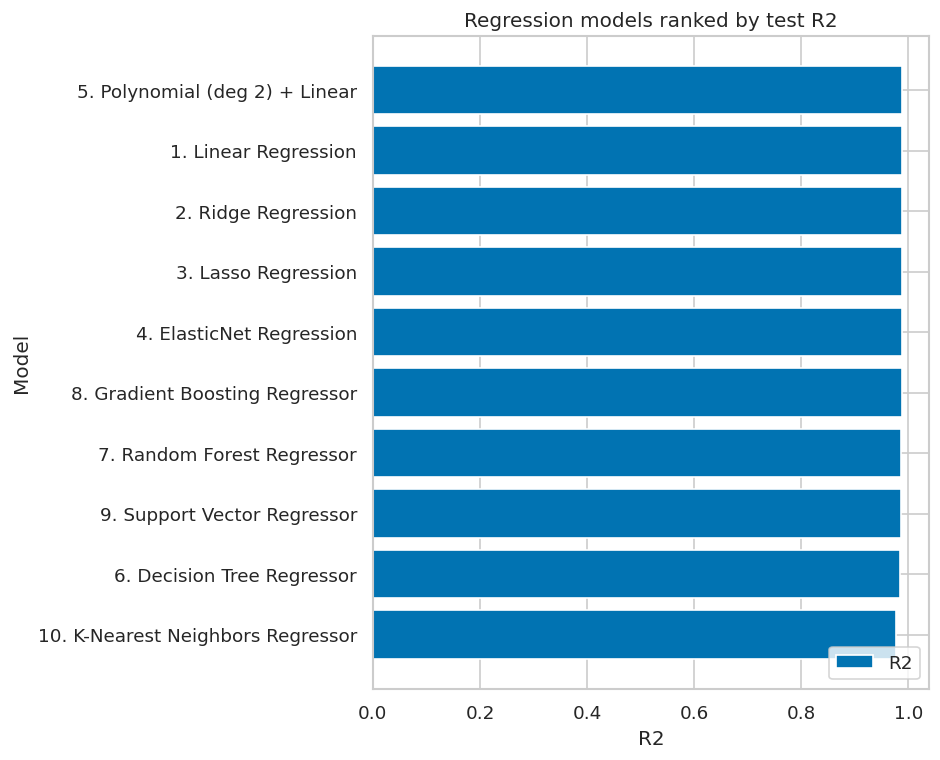

In [20]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Comparative results
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Which model ranks first on test R², and by how much does it beat the linear baseline?
> 2. Is that margin large enough to matter, given the RMSE is in Performance-Index points?
> 3. What does it tell you that the regularised linear models and the ensembles land so close together?
>
> ---
>
> *(your written observation here)*

## 5. Cross-validation  *(Rubric: 5-fold CV R² for the two best models)*
Leading models are nominated using **training-side** cross-validation. The
held-out test set plays no part in selection.

In [21]:
cv_all = ev.cv_scores(models, X_train, y_train, scoring="r2")
cv_all.drop(columns="fold_scores")

  1. Linear Regression               r2 CV = 0.9887 (+/- 0.0003)
  2. Ridge Regression                r2 CV = 0.9887 (+/- 0.0003)


  3. Lasso Regression                r2 CV = 0.9887 (+/- 0.0003)


  4. ElasticNet Regression           r2 CV = 0.9886 (+/- 0.0002)
  5. Polynomial (deg 2) + Linear     r2 CV = 0.9886 (+/- 0.0003)


  6. Decision Tree Regressor         r2 CV = 0.9825 (+/- 0.0006)


  7. Random Forest Regressor         r2 CV = 0.9851 (+/- 0.0003)


  8. Gradient Boosting Regressor     r2 CV = 0.9879 (+/- 0.0003)


  9. Support Vector Regressor        r2 CV = 0.9849 (+/- 0.0006)
  10. K-Nearest Neighbors Regressor  r2 CV = 0.9740 (+/- 0.0013)


,Model,scoring,folds,CV_mean,CV_std
0,1. Linear Regression,r2,5,0.988661,0.000283
1,2. Ridge Regression,r2,5,0.988661,0.000282
2,3. Lasso Regression,r2,5,0.988659,0.000275
3,4. ElasticNet Regression,r2,5,0.988632,0.000243
4,5. Polynomial (deg 2) + Linear,r2,5,0.988618,0.000289
5,6. Decision Tree Regressor,r2,5,0.982533,0.000597
6,7. Random Forest Regressor,r2,5,0.985103,0.000307
7,8. Gradient Boosting Regressor,r2,5,0.987947,0.000324
8,9. Support Vector Regressor,r2,5,0.984944,0.000563
9,10. K-Nearest Neighbors Regressor,r2,5,0.973987,0.001278


In [22]:
leaders = cv_all.sort_values("CV_mean", ascending=False)["Model"].head(2).tolist()
print("leaders selected on training CV:", leaders)
cv_all[cv_all["Model"].isin(leaders)][["Model","CV_mean","CV_std","fold_scores"]]

leaders selected on training CV: ['1. Linear Regression', '2. Ridge Regression']


,Model,CV_mean,CV_std,fold_scores
0,1. Linear Regression,0.988661,0.000283,"[0.98872, 0.98838, 0.98891, 0.98829, 0.989]"
1,2. Ridge Regression,0.988661,0.000282,"[0.98872, 0.98839, 0.98891, 0.98829, 0.989]"


## 6. Hyperparameter tuning  *(Rubric C3)*
`GridSearchCV` on at least two models. Before/after scores are reported on both
the CV score used for selection and the held-out set. **If tuning does not
improve a model, that is what gets reported.**

In [23]:
import json
tunable = [m for m in leaders if m in rm.PARAM_GRIDS]
for cand in rm.PARAM_GRIDS:
    if len(tunable) >= 2: break
    if cand not in tunable: tunable.append(cand)
print("tuning:", tunable)

rows = {}
tuned = {}
for name in tunable:
    base_cv = float(cv_all.loc[cv_all["Model"] == name, "CV_mean"].iloc[0])
    base_test = float(table.loc[table["Model"] == name, "R2"].iloc[0])
    gs = rm.tune(name, models[name], X_train, y_train)
    after = ev.regression_metrics(y_test, gs.best_estimator_.predict(X_test))
    rows[name] = {"best_params": gs.best_params_,
                  "CV_R2_before": round(base_cv, 5), "CV_R2_after": round(gs.best_score_, 5),
                  "HeldOut_R2_before": round(base_test, 5),
                  "HeldOut_R2_after": round(after["R2"], 5),
                  "improved_on_CV": bool(gs.best_score_ > base_cv)}
    tuned[name] = gs.best_estimator_
pd.DataFrame(rows).T

tuning: ['2. Ridge Regression', '3. Lasso Regression']


  [tuned] 2. Ridge Regression: best r2=0.9887 params={'model__alpha': 0.1}


  [tuned] 3. Lasso Regression: best r2=0.9887 params={'model__alpha': 0.001}


,best_params,CV_R2_before,CV_R2_after,HeldOut_R2_before,HeldOut_R2_after,improved_on_CV
2. Ridge Regression,{'model__alpha': 0.1},0.98866,0.98866,0.98898,0.98898,True
3. Lasso Regression,{'model__alpha': 0.001},0.98866,0.98866,0.98897,0.98898,True


> ### ✍️ TEAM TO COMPLETE — Tuning outcome
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Did tuning change the score meaningfully, or only in the fourth decimal place?
> 2. What does the size of the improvement suggest about whether these models were under-regularised to begin with?
> 3. Would you ship the tuned or the default configuration, and why?
>
> ---
>
> *(your written observation here)*

## 7. Algorithm-specific requirements from the PDF
Coefficient interpretation (#1), Lasso sparsity (#3), polynomial degree
comparison (#5), tree feature importance (#6/#7).

In [24]:
coefs = rm.coefficient_table(fitted["1. Linear Regression"])
print("intercept:", round(coefs.attrs["intercept"], 4))
print("NOTE: numeric inputs are standardised, so each coefficient is the change "
      "in Performance Index per 1 standard deviation of that feature.")
coefs

intercept: 55.0105
NOTE: numeric inputs are standardised, so each coefficient is the change in Performance Index per 1 standard deviation of that feature.


,feature,coefficient
0,Previous Scores,17.637271
1,Hours Studied,7.401341
2,Sleep Hours,0.810031
3,Extracurricular Activities_Yes,0.608617
4,Sample Question Papers Practiced,0.548842


> ### ✍️ TEAM TO COMPLETE — Coefficient interpretation
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. State in one sentence, in plain language, what the largest coefficient means for a student.
> 2. Do the signs of all coefficients match your domain expectation?
>
> ---
>
> *(your written observation here)*

In [25]:
rm.sparsity_report(fitted["3. Lasso Regression"])

{'n_features': 5,
 'n_zero_coefficients': 0,
 'zeroed_features': [],
 'pct_zero': 0.0}

In [26]:
poly = rm.polynomial_degree_comparison(['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced'], ['Extracurricular Activities'], X_train, y_train, X_test, y_test,
                                       degrees=(1, 2, 3))
poly

,degree,n_expanded_terms,train_R2,test_R2,test_RMSE,test_MAE
0,1,5,0.988690,0.988983,2.020552,1.611121
1,2,20,0.988705,0.988989,2.020060,1.611523
2,3,55,0.988756,0.988958,2.022907,1.611932


> ### ✍️ TEAM TO COMPLETE — Lasso sparsity and polynomial degree
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. How many coefficients did Lasso drive to zero, and what does that imply about redundant features?
> 2. Compare train R² and test R² as the polynomial degree rises. At which degree does overfitting begin, and how do you see it?
>
> ---
>
> *(your written observation here)*

## 8. Required visualisations  *(Rubric C4)*

In [27]:
best_name = table.sort_values("R2", ascending=False).iloc[0]["Model"]
best_model = tuned.get(best_name, fitted[best_name])
y_pred = best_model.predict(X_test)
print("best model on held-out R2:", best_name)
p1 = pl.residual_plot(y_test, y_pred, best_name, "nb_reg_residuals", "regression")
p2 = pl.predicted_vs_actual(y_test, y_pred, best_name, "nb_reg_pred_vs_actual", "regression")

best model on held-out R2: 5. Polynomial (deg 2) + Linear


[fig] results/figures/regression/nb_reg_residuals.png
[fig] results/figures/regression/nb_reg_pred_vs_actual.png


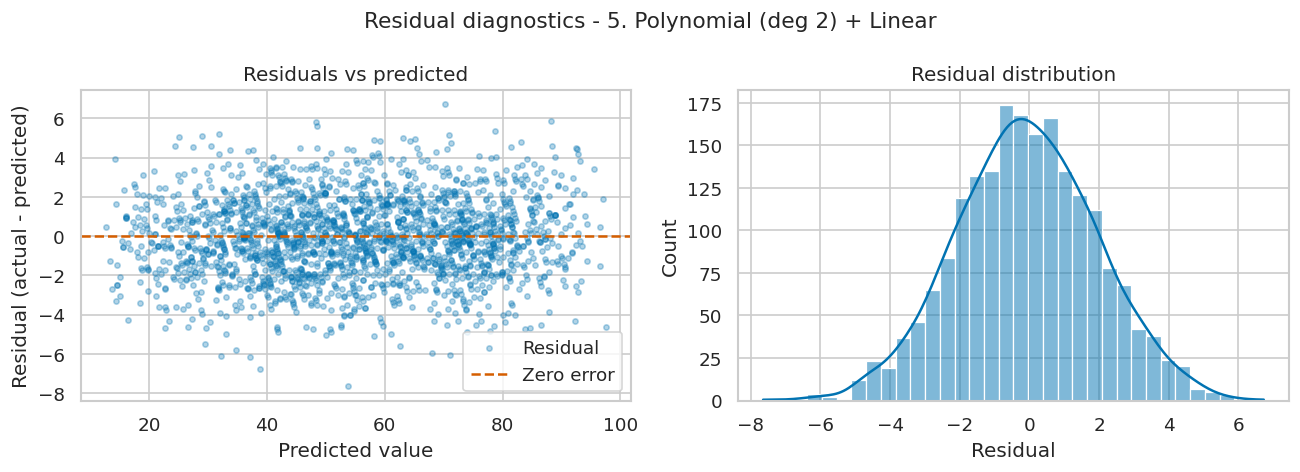

In [28]:
from IPython.display import Image, display
display(Image(filename=str(p1)))

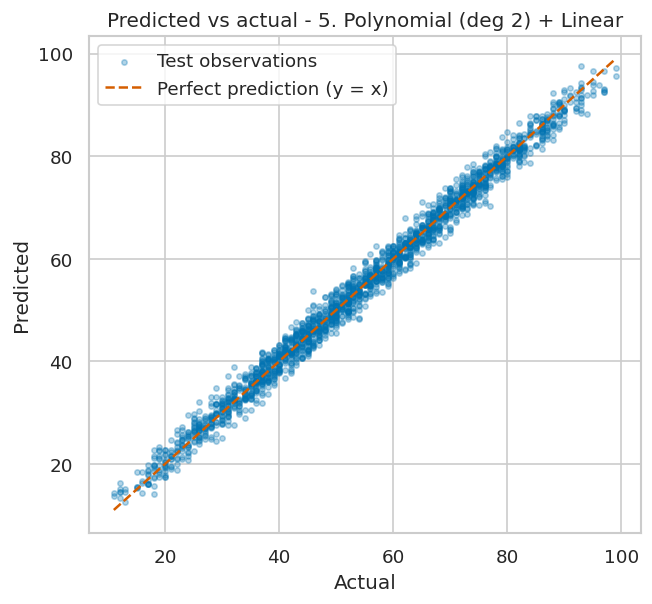

In [29]:
from IPython.display import Image, display
display(Image(filename=str(p2)))

> ### ✍️ TEAM TO COMPLETE — Residual diagnostics
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Are residuals centred on zero and roughly constant across the predicted range, or do they fan out?
> 2. Does the residual histogram look approximately normal?
> 3. What would a visible pattern here tell you about a missing feature or a missing non-linear term?
>
> ---
>
> *(your written observation here)*

In [30]:
imp = rm.tree_importances(fitted["7. Random Forest Regressor"])
p = pl.importance_plot(imp.values, imp.index, "Random Forest Regressor - feature importance",
                       "nb_reg_feature_importance", "regression", xlabel="Gini importance")
imp

[fig] results/figures/regression/nb_reg_feature_importance.png


Previous Scores                     0.846778
Hours Studied                       0.141897
Sample Question Papers Practiced    0.005181
Sleep Hours                         0.004806
Extracurricular Activities_Yes      0.001338
dtype: float64

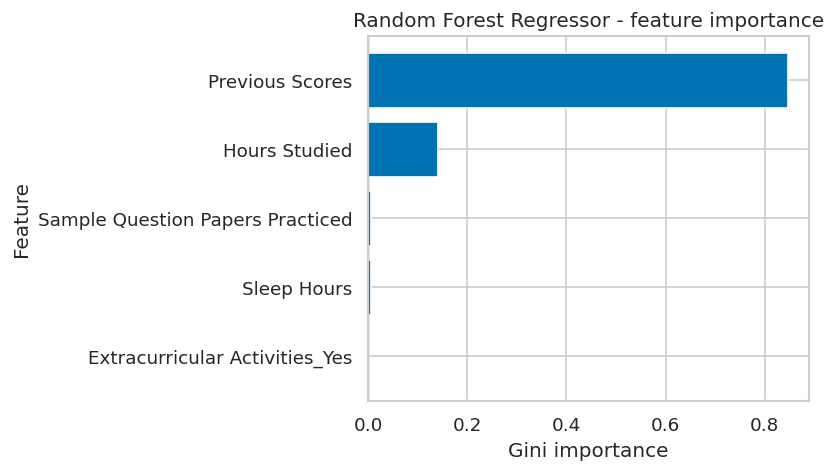

In [31]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### ✍️ TEAM TO COMPLETE — Feature importance vs linear coefficients
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Do the Random Forest importances rank the features the same way the linear coefficients do?
> 2. Where they disagree, which do you trust for this dataset, and why?
>
> ---
>
> *(your written observation here)*

## 9. Review 1 summary

Fill in the conclusion yourself — this is explicitly excluded from AI assistance.

> ### ✍️ TEAM TO COMPLETE — Regression track conclusion
>
> *This cell is intentionally left unwritten. Section 7.5 of the guidelines
> requires that analysis and interpretation are the team's own work. Replace
> everything below the line with your own observations.*
>
> **Guiding questions**
>
> 1. Which model do you nominate as final, and on what evidence (test metric, CV stability, simplicity, training cost)?
> 2. What is the practical meaning of the RMSE in Performance-Index points?
> 3. What is the main limitation of this dataset, given that it is synthetic?
> 4. What would you do next if you had another week?
>
> ---
>
> *(your written observation here)*